<a href="https://colab.research.google.com/github/johnlaraji1608-collab/Ridge_Regression/blob/main/HittersDataset_RidgeRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import numpy as np
Hitters=pd.read_csv("/content/Hitters.csv")
df=Hitters.copy()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [ ]:
df.describe

<bound method NDFrame.describe of      AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  \
0      293    66      1    30   29     14      1     293     66       1   
1      315    81      7    24   38     39     14    3449    835      69   
2      479   130     18    66   72     76      3    1624    457      63   
3      496   141     20    65   78     37     11    5628   1575     225   
4      321    87     10    39   42     30      2     396    101      12   
..     ...   ...    ...   ...  ...    ...    ...     ...    ...     ...   
317    497   127      7    65   48     37      5    2703    806      32   
318    492   136      5    76   50     94     12    5511   1511      39   
319    475   126      3    61   43     52      6    1700    433       7   
320    573   144      9    85   60     78      8    3198    857      97   
321    631   170      9    77   44     31     11    4908   1457      30   

     CRuns  CRBI  CWalks League Division  PutOuts  Assists  Errors  Salary  \
0       30    29      14      A        E      446       33      20     NaN   
1      321   414     375      N        W      632       43      10   475.0   
2      224   266     263      A        W      880       82      14   480.0   
3      828   838     354      N        E      200       11       3   500.0   
4       48    46      33      N        E      805       40       4    91.5   
..     ...   ...     ...    ...      ...      ...      ...     ...     ...   
317    379   311     138      N        E      325        9       3   700.0   
318    897   451     875      A        E      313      381      20   875.0   
319    217    93     146      A        W       37      113       7   385.0   
320    470   420     332      A        E     1314      131      12   960.0   
321    775   357     249      A        W      408        4       3  1000.0   

    NewLeague  
0           A  
1           N  
2           A  
3           N  
4           N  
..        ...  
317         N  
318         A  
319         A  
320         A  
321         A  

[322 rows x 20 columns]>

In [ ]:
df.isnull().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


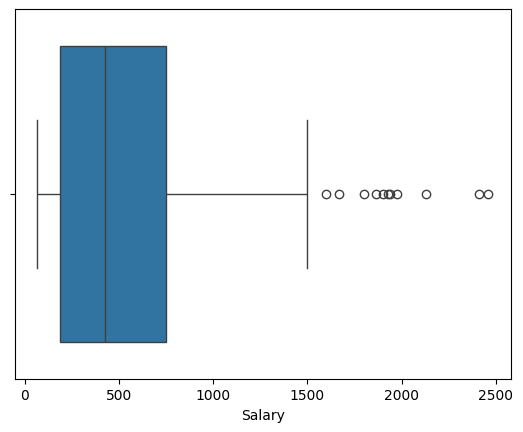

In [ ]:
import seaborn as sns
sns.boxplot(x=df["Salary"]);

In [ ]:
NAdf= df[df.isnull().any(axis=1)]
NAdf.describe().T

,count,mean,std,min,25%,50%,75%,max
AtBat,59.0,279.677966,139.477898,16.0,197.5,249.0,352.5,580.0
Hits,59.0,70.694915,39.994075,2.0,45.5,61.0,94.0,194.0
HmRun,59.0,6.983051,7.449813,0.0,1.5,5.0,9.0,35.0
Runs,59.0,33.813559,20.921425,1.0,20.0,30.0,44.5,91.0
RBI,59.0,32.610169,21.616578,0.0,18.5,29.0,42.5,94.0
Walks,59.0,28.169492,17.935856,0.0,16.0,25.0,37.5,87.0
Years,59.0,8.033898,5.483411,1.0,4.0,7.0,12.0,23.0
CAtBat,59.0,2609.186441,2505.342123,28.0,704.5,1407.0,4333.5,9778.0
CHits,59.0,697.000000,687.099501,4.0,171.0,361.0,1060.0,2732.0
CHmRun,59.0,70.610169,103.269820,0.0,9.5,28.0,66.5,442.0


In [ ]:
notNAdf=df[df.notnull().all(axis=1)]
notNAdf.describe().T

,count,mean,std,min,25%,50%,75%,max
AtBat,263.0,403.642586,147.307209,19.0,282.5,413.0,526.0,687.0
Hits,263.0,107.828897,45.125326,1.0,71.5,103.0,141.5,238.0
HmRun,263.0,11.619772,8.757108,0.0,5.0,9.0,18.0,40.0
Runs,263.0,54.745247,25.539816,0.0,33.5,52.0,73.0,130.0
RBI,263.0,51.486692,25.882714,0.0,30.0,47.0,71.0,121.0
Walks,263.0,41.114068,21.718056,0.0,23.0,37.0,57.0,105.0
Years,263.0,7.311787,4.793616,1.0,4.0,6.0,10.0,24.0
CAtBat,263.0,2657.543726,2286.582929,19.0,842.5,1931.0,3890.5,14053.0
CHits,263.0,722.186312,648.199644,4.0,212.0,516.0,1054.0,4256.0
CHmRun,263.0,69.239544,82.197581,0.0,15.0,40.0,92.5,548.0


In [ ]:
notNAdf.corr

<bound method DataFrame.corr of      AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  \
1      315    81      7    24   38     39     14    3449    835      69   
2      479   130     18    66   72     76      3    1624    457      63   
3      496   141     20    65   78     37     11    5628   1575     225   
4      321    87     10    39   42     30      2     396    101      12   
5      594   169      4    74   51     35     11    4408   1133      19   
..     ...   ...    ...   ...  ...    ...    ...     ...    ...     ...   
317    497   127      7    65   48     37      5    2703    806      32   
318    492   136      5    76   50     94     12    5511   1511      39   
319    475   126      3    61   43     52      6    1700    433       7   
320    573   144      9    85   60     78      8    3198    857      97   
321    631   170      9    77   44     31     11    4908   1457      30   

     CRuns  CRBI  CWalks League Division  PutOuts  Assists  Errors  Salary  \
1      321   414     375      N        W      632       43      10   475.0   
2      224   266     263      A        W      880       82      14   480.0   
3      828   838     354      N        E      200       11       3   500.0   
4       48    46      33      N        E      805       40       4    91.5   
5      501   336     194      A        W      282      421      25   750.0   
..     ...   ...     ...    ...      ...      ...      ...     ...     ...   
317    379   311     138      N        E      325        9       3   700.0   
318    897   451     875      A        E      313      381      20   875.0   
319    217    93     146      A        W       37      113       7   385.0   
320    470   420     332      A        E     1314      131      12   960.0   
321    775   357     249      A        W      408        4       3  1000.0   

    NewLeague  
1           N  
2           A  
3           N  
4           N  
5           A  
..        ...  
317         N  
318         A  
319         A  
320         A  
321         A  

[263 rows x 20 columns]>

In [ ]:
print("New League= A" ,notNAdf[notNAdf["NewLeague"]=="A"].agg({"Salary":"mean"}))
print("New League= N" ,notNAdf[notNAdf["NewLeague"]=="N"].agg({"Salary":"mean"}))
print("League= A" ,notNAdf[notNAdf["League"]=="A"].agg({"Salary":"mean"}))
print("League= N" ,notNAdf[notNAdf["League"]=="N"].agg({"Salary":"mean"}))
print("Division= E" ,notNAdf[notNAdf["Division"]=="E"].agg({"Salary":"mean"}))
print("Division= W" ,notNAdf[notNAdf["Division"]=="W"].agg({"Salary":"mean"}))

New League= A Salary    537.113028
dtype: float64
New League= N Salary    534.553852
dtype: float64
League= A Salary    541.999547
dtype: float64
League= N Salary    529.1175
dtype: float64
Division= E Salary    624.271364
dtype: float64
Division= W Salary    450.876873
dtype: float64


In [ ]:
df.head(2)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N


In [ ]:
df.loc[(df["Salary"].isnull())& (df['Division'] == 'E'),"Salary"]=624.27
df.head(2)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,624.27,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.00,N


In [ ]:
df.loc[(df["Salary"].isnull())& (df['Division'] == 'W'),"Salary"]=450.87
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df[df["Salary"]<0]

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague


In [ ]:
dff = pd.get_dummies(df, columns = ['League', 'Division', 'NewLeague'], drop_first = True)
dff.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,624.27,False,False,False
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.00,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.00,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.00,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.50,True,False,True


In [ ]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor(n_neighbors = 20, contamination = 0.05)
clf.fit_predict(dff)
dff_scores = clf.negative_outlier_factor_
np.sort(dff_scores)[0:20]

array([-4.72760892, -3.46603588, -2.39248078, -2.31959428, -1.89668479,
       -1.89215368, -1.88689919, -1.85298306, -1.83851027, -1.80132619,
       -1.66642575, -1.64463411, -1.64404063, -1.56696038, -1.54942116,
       -1.51116262, -1.50646388, -1.46830817, -1.46601596, -1.45557139])

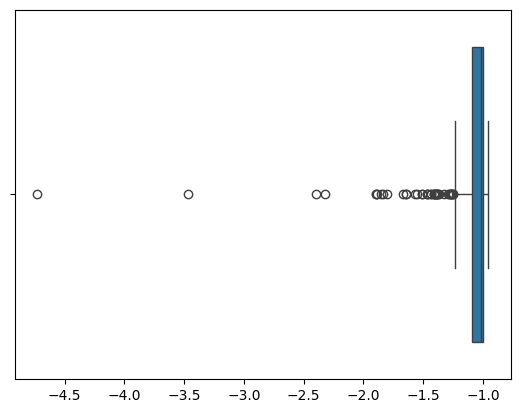

In [ ]:
sns.boxplot(x=dff_scores);

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

y=dff["Salary"]
X=dff.drop("Salary", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=46)

ridge_model=Ridge().fit(X_train,y_train)
y_pred= ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(326.2161070863074)

In [ ]:
from sklearn.linear_model import RidgeCV
alphas1 = np.random.randint(0,1000,100)
alphas2 = 10**np.linspace(10,-2,100)*0.5
alphas3 = np.linspace(0,1,1000)
ridge_cv = RidgeCV(alphas = alphas1, scoring = "neg_mean_squared_error", cv = 10, normalize = True)
ridge_cv.fit(X_train,y_train)
ridge_cv.alpha_

TypeError: _BaseRidgeCV.__init__() got an unexpected keyword argument 'normalize'

In [ ]:
ridge_tuned=Ridge(alpha=ridge_cv.alpha_).fit(X_train,y_train)
y_pred=ridge_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

NameError: name 'ridge_cv' is not defined